In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("exchange_rate.csv")

In [3]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [5]:
df.isnull().sum()

,0
date,0
Ex_rate,0


In [7]:
df.shape

(7588, 2)

In [8]:
df.columns

Index(['date', 'Ex_rate'], dtype='object')

In [9]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df.set_index('date', inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


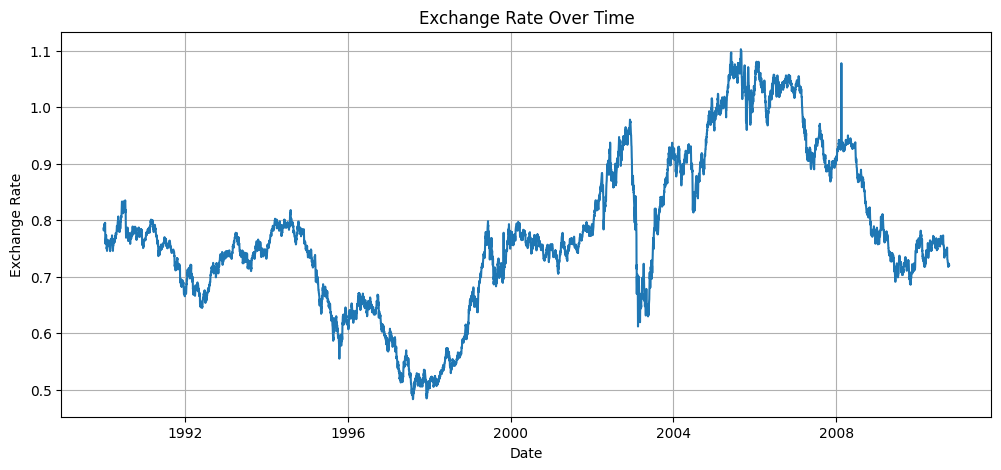

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df['Ex_rate'])
plt.title("Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()

In [11]:
train = df.iloc[:7000]
test = df.iloc[7000:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (7000, 1)
Test Shape: (588, 1)


In [12]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Ex_rate'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7000
Model:                 ARIMA(5, 1, 0)   Log Likelihood               25763.583
Date:                Mon, 27 Jul 2026   AIC                         -51515.165
Time:                        12:01:30   BIC                         -51474.044
Sample:                    01-01-1990   HQIC                        -51500.995
                         - 03-01-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1327      0.002    -61.805      0.000      -0.137      -0.128
ar.L2         -0.0049      0.006     -0.763      0.445      -0.018       0.008
ar.L3         -0.0171      0.007     -2.410      0.0

In [13]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Ex_rate'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7000
Model:                 ARIMA(5, 1, 0)   Log Likelihood               25763.583
Date:                Mon, 27 Jul 2026   AIC                         -51515.165
Time:                        12:03:07   BIC                         -51474.044
Sample:                    01-01-1990   HQIC                        -51500.995
                         - 03-01-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1327      0.002    -61.805      0.000      -0.137      -0.128
ar.L2         -0.0049      0.006     -0.763      0.445      -0.018       0.008
ar.L3         -0.0171      0.007     -2.410      0.0

In [15]:
forecast = model_fit.forecast(steps=len(test))

forecast = pd.Series(forecast, index=test.index)

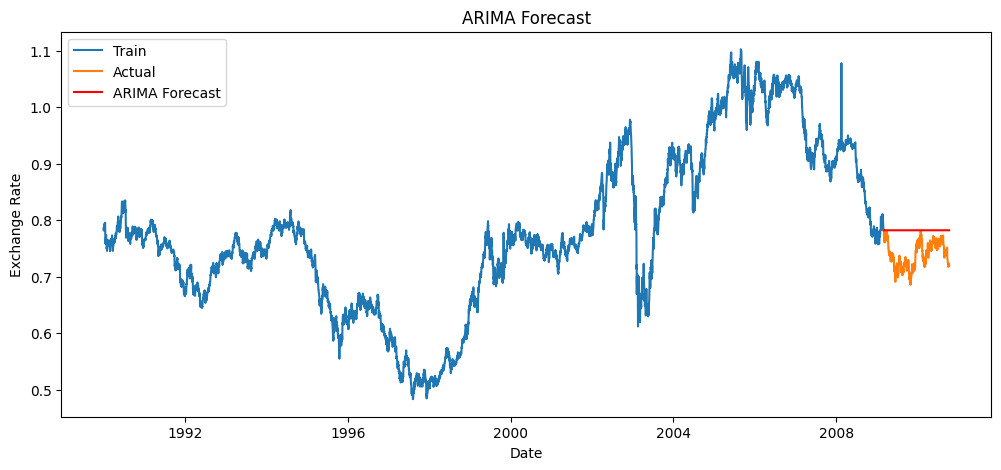

In [16]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(forecast.index, forecast, label='ARIMA Forecast', color='red')

plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()

plt.show()

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['Ex_rate'], forecast)
rmse = np.sqrt(mean_squared_error(test['Ex_rate'], forecast))
mape = np.mean(np.abs((test['Ex_rate'] - forecast) / test['Ex_rate'])) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 0.043222706790561255
RMSE: 0.04873080733554685
MAPE: 5.947916456561112


In [18]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(train['Ex_rate'], trend='add', seasonal=None)
exp_fit = exp_model.fit()

exp_forecast = exp_fit.forecast(len(test))
exp_forecast = pd.Series(exp_forecast, index=test.index)

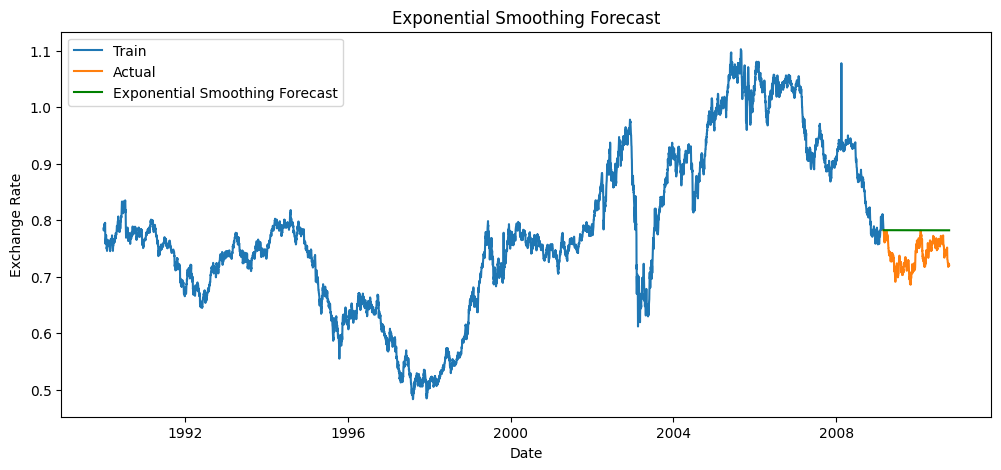

In [19]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(exp_forecast.index, exp_forecast, label='Exponential Smoothing Forecast', color='green')

plt.title("Exponential Smoothing Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()

plt.show()

In [20]:
mae_exp = mean_absolute_error(test['Ex_rate'], exp_forecast)
rmse_exp = np.sqrt(mean_squared_error(test['Ex_rate'], exp_forecast))
mape_exp = np.mean(np.abs((test['Ex_rate'] - exp_forecast) / test['Ex_rate'])) * 100

print("MAE :", mae_exp)
print("RMSE:", rmse_exp)
print("MAPE:", mape_exp)

MAE : 0.04329254351693889
RMSE: 0.048802375890780764
MAPE: 5.957463125868894


In [21]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "Exponential Smoothing"],
    "MAE": [mae, mae_exp],
    "RMSE": [rmse, rmse_exp],
    "MAPE": [mape, mape_exp]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.043223,0.048731,5.947916
1,Exponential Smoothing,0.043293,0.048802,5.957463


In [23]:
print("Conclusion")
print("1. Historical exchange rate data was analyzed.")
print("2. ARIMA and Exponential Smoothing models were built.")
print("3. Forecasts were generated for the test data.")
print("4. MAE, RMSE and MAPE were used to evaluate the models.")
print("5. ARIMA achieved slightly lower error values than Exponential Smoothing.")
print("6. Therefore, ARIMA is the better forecasting model for this dataset.")

Conclusion
1. Historical exchange rate data was analyzed.
2. ARIMA and Exponential Smoothing models were built.
3. Forecasts were generated for the test data.
4. MAE, RMSE and MAPE were used to evaluate the models.
5. ARIMA achieved slightly lower error values than Exponential Smoothing.
6. Therefore, ARIMA is the better forecasting model for this dataset.
